# GPU horizontal-resolution scaling test

How does wall-clock cost scale with horizontal resolution, for both Jupiter models, on this machine's single NVIDIA A40? This is a pilot single-GPU test ahead of running the same kind of sweep across multiple GPUs elsewhere.

**Method:** starting from T21, repeatedly double the horizontal resolution (T21 -> T42 -> T85 -> T170 -> T340, doubling both the spectral truncation and the number of Gaussian latitude/longitude nodes each step) while halving the timestep each time to keep the CFL number roughly constant. Vertical resolution (60 log-spaced sigma levels) is held fixed throughout -- only horizontal resolution is varied.

**Metric:** wall-clock time to simulate 3 Earth days, at each resolution, for both `lian_showman` and `grey_radiation`.

**Extrapolation, not a literal run:** with a CFL-limited timestep, the number of steps needed for a fixed simulated duration doubles every time resolution doubles, on top of each step getting more expensive -- so literally running all the way to 3 simulated days at the higher resolutions would be impractically slow. Instead, each resolution is benchmarked with a short, fixed number of timesteps (compiled once, timed on a second call so JIT compilation isn't counted), and the steady-state ms/step is extrapolated to the number of steps 3 days would actually take at that resolution's timestep. This is standard practice for scaling studies and was checked to give a stable, repeatable ms/step at each resolution.

**Where this GPU's limit is:** T340 (a 1024x512 nodal grid) already uses ~30GB just for compile-time constants (spectral-transform operator matrices, which grow with resolution) on this 46GB A40 -- found by testing up from T21 first. The next doubling (T680) would need roughly 4x that and was not attempted. So T340 is treated as this single GPU's practical ceiling for these models; a multi-GPU run would be needed to go further, which is exactly what this pilot is meant to inform.

In [1]:
import sys
sys.path.insert(0, '.')  # so `jupiter_gcm_utils` (in this directory) imports

import dinosaur
import jax
import matplotlib.pyplot as plt
import numpy as np

import jupiter_gcm_utils as jgu

units = dinosaur.scales.units

print('jax version:', jax.__version__)
print('devices:', jax.devices())

jax version: 0.11.1


devices: [CudaDevice(id=0)]


In [2]:
# (max_wavenumber, gaussian_nodes, dt) -- gaussian_nodes and max_wavenumber
# both double each step (T21 -> T42 -> T85 -> T170 -> T340); dt halves each
# step to keep the CFL number roughly constant. The base dt (20 min at T21,
# i.e. 10 min at T42) matches what's already validated as stable in the
# individual demo notebooks.
resolutions = [
    (21, 16, 20 * units.minute),
    (42, 32, 10 * units.minute),
    (85, 64, 5 * units.minute),
    (170, 128, 2.5 * units.minute),
    (340, 256, 1.25 * units.minute),
]

total_time = 3 * units.day
benchmark_steps = 20

In [3]:
all_results = {}
for model_name in ['lian_showman', 'grey_radiation']:
  print(f'=== {model_name} ===')
  all_results[model_name] = jgu.resolution_scaling_sweep(
      model_name, resolutions, total_time_si=total_time,
      benchmark_steps=benchmark_steps,
  )
  print()

=== lian_showman ===
lian_showman: max_wavenumber=21, gaussian_nodes=16, dt=20 minute


  ms/step=0.57, implied wall time=0.1s
lian_showman: max_wavenumber=42, gaussian_nodes=32, dt=10 minute


  ms/step=1.93, implied wall time=0.8s
lian_showman: max_wavenumber=85, gaussian_nodes=64, dt=5 minute


  ms/step=7.87, implied wall time=6.8s
lian_showman: max_wavenumber=170, gaussian_nodes=128, dt=2.5 minute


/home/links/sit204/miniforge3/envs/dino/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1286: UserWarning: A large amount of constants were captured during lowering (3.88GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


...

  ms/step=12.59, implied wall time=10.9s
grey_radiation: max_wavenumber=170, gaussian_nodes=128, dt=2.5 minute


/home/links/sit204/miniforge3/envs/dino/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1286: UserWarning: A large amount of constants were captured during lowering (3.69GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


  ms/step=48.87, implied wall time=84.4s
grey_radiation: max_wavenumber=340, gaussian_nodes=256, dt=1.25 minute


/home/links/sit204/miniforge3/envs/dino/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1286: UserWarning: A large amount of constants were captured during lowering (28.89GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


  ms/step=281.85, implied wall time=974.1s



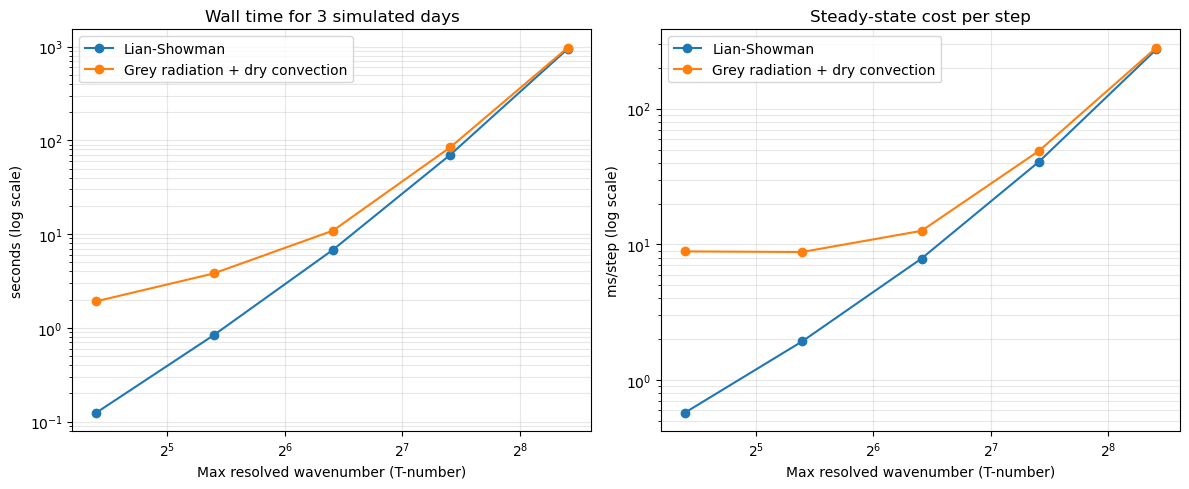

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'lian_showman': 'C0', 'grey_radiation': 'C1'}
labels = {'lian_showman': 'Lian-Showman', 'grey_radiation': 'Grey radiation + dry convection'}

for model_name, results in all_results.items():
  ok = [r for r in results if r['error'] is None]
  mw = [r['max_wavenumber'] for r in ok]
  wall = [r['implied_wall_seconds'] for r in ok]
  ms = [r['ms_per_step'] for r in ok]
  color = colors[model_name]
  axes[0].plot(mw, wall, 'o-', color=color, label=labels[model_name])
  axes[1].plot(mw, ms, 'o-', color=color, label=labels[model_name])

for ax, title, ylabel in zip(
    axes,
    ['Wall time for 3 simulated days', 'Steady-state cost per step'],
    ['seconds (log scale)', 'ms/step (log scale)'],
):
  ax.set_xscale('log', base=2)
  ax.set_yscale('log')
  ax.set_xlabel('Max resolved wavenumber (T-number)')
  ax.set_ylabel(ylabel)
  ax.set_title(title)
  ax.legend()
  ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()

In [5]:
for model_name, results in all_results.items():
  print(f'--- {model_name} ---')
  ok = [r for r in results if r['error'] is None]
  print(f'{"T-number":>10} {"nodes (lon x lat)":>20} {"ms/step":>10} '
        f'{"3-day wall (s)":>16} {"exponent p":>12}')
  prev = None
  for r in ok:
    p_str = ''
    if prev is not None:
      ratio = r['implied_wall_seconds'] / prev['implied_wall_seconds']
      res_ratio = r['max_wavenumber'] / prev['max_wavenumber']
      p_str = f'{np.log(ratio) / np.log(res_ratio):.2f}'
    print(f'{r["max_wavenumber"]:>10} '
          f'{r["longitude_nodes"]:>8} x {r["latitude_nodes"]:<8} '
          f'{r["ms_per_step"]:>10.2f} {r["implied_wall_seconds"]:>16.1f} '
          f'{p_str:>12}')
    prev = r
  failed = [r for r in results if r['error'] is not None]
  if failed:
    print(f'  (stopped: {failed[0]["error"]})')
  print()

--- lian_showman ---
  T-number    nodes (lon x lat)    ms/step   3-day wall (s)   exponent p
        21       64 x 32             0.57              0.1             
        42      128 x 64             1.93              0.8         2.75
        85      256 x 128            7.87              6.8         2.98
       170      512 x 256           40.66             70.3         3.37
       340     1024 x 512          273.88            946.5         3.75

--- grey_radiation ---
  T-number    nodes (lon x lat)    ms/step   3-day wall (s)   exponent p
        21       64 x 32             8.88              1.9             
        42      128 x 64             8.79              3.8         0.99
        85      256 x 128           12.59             10.9         1.49
       170      512 x 256           48.87             84.4         2.96
       340     1024 x 512          281.85            974.1         3.53



## Scaling exponent per doubling

For each successive resolution doubling, the local power-law exponent `p` such that cost scales as `resolution^p` (i.e. `p = log2(cost_ratio)`), computed from the 3-day implied wall time. For reference: spectral-transform cost alone is typically expected to scale close to `resolution^3` for this style of dycore.

## Results

Wall-clock time to simulate 3 Earth days (extrapolated from steady-state ms/step) vs. horizontal resolution, on a log-log scale -- a straight line here means power-law scaling, and its slope is the scaling exponent (e.g. slope 3 means cost ~ resolution^3).